In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Amazon_Reviews.csv to Amazon_Reviews.csv


In [ ]:
df=pd.read_csv("Amazon_Reviews.csv", engine='python', on_bad_lines='skip')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21214 entries, 0 to 21213
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Reviewer Name       21214 non-null  object
 1   Profile Link        21163 non-null  object
 2   Country             21054 non-null  object
 3   Review Count        21055 non-null  object
 4   Review Date         21055 non-null  object
 5   Rating              21055 non-null  object
 6   Review Title        21055 non-null  object
 7   Review Text         21055 non-null  object
 8   Date of Experience  20947 non-null  object
dtypes: object(9)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
Reviewer Name,0
Profile Link,51
Country,160
Review Count,159
Review Date,159
Rating,159
Review Title,159
Review Text,159
Date of Experience,267


In [ ]:
df['Rating'] = df['Rating'].astype(str).str.extract(r'(\d+)', expand=False).astype(float)
df['sentiment'] = df['Rating'].apply(lambda x: 1 if x>=3 else 0)

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def clean_text(text):
  text = str(text) # Ensure text is string
  text = text.lower() # Convert to lowercase
  text = re.sub('[^a-zA-Z]', ' ', text) # Replace non-alphabetic with space
  words = text.split() # Split into words
  words = [
      word for word in words if word not in stopwords.words('english')
  ]
  return ' '.join(words) # Join back with spaces

In [ ]:
def clean_text(text):
  text = str(text) # Ensure text is string
  text = text.lower() # Convert to lowercase
  text = re.sub('[^a-zA-Z]', ' ', text) # Replace non-alphabetic with space
  words = text.split() # Split into words
  words = [
      word for word in words if word not in stopwords.words('english')
  ]
  return ' '.join(words) # Join back with spaces

df['clean_review'] = df['Review Text'].apply(clean_text)

In [ ]:
tfidf=TfidfVectorizer(max_features=3000)
x=tfidf.fit_transform(
    df['clean_review']
).toarray()
y=df['sentiment']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of x_train: (16971, 3000)
Shape of y_train: (16971,)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(x_train,y_train)

MultinomialNB()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9102050436012256


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2928
           1       0.92      0.78      0.84      1315

    accuracy                           0.91      4243
   macro avg       0.91      0.87      0.89      4243
weighted avg       0.91      0.91      0.91      4243



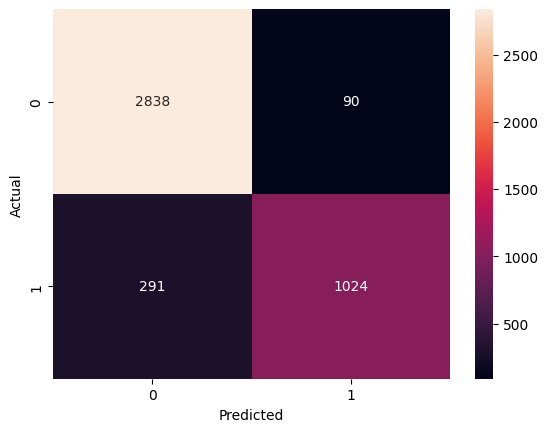

In [ ]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import joblib
joblib.dump(model,'sentiment_model.pkl')

['sentiment_model.pkl']

In [ ]:
review="This product is amazing"
review=clean_text(review)
review_vector=tfidf.transform([review]).toarray()
prediction=model.predict(review_vector)
if prediction[0]==1:
  print("Positive Review")
else:
  print("Negative Review")

Positive Review


In [ ]:
print(df.columns)

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience', 'sentiment', 'clean_review'],
      dtype='object')


In [ ]:
from google.colab import files
files.download('sentiment_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>